
Total Classes: 31

Processing train...


100%|██████████| 9690/9690 [00:45<00:00, 215.16it/s]



Processing valid...


100%|██████████| 2760/2760 [00:13<00:00, 205.29it/s]



Processing test...


100%|██████████| 1380/1380 [00:06<00:00, 216.11it/s]



========== DATASET SUMMARY ==========
Total Images      : 13830
Total Labels      : 135794
Empty Labels      : 16
Average Boxes/Image : 9.82

Class Distribution:
    Class ID            Class Name  Count
0          4               Filling  48694
4         23        impacted tooth  27872
1         14  Root Canal Treatment  18887
5          2                 Crown  11155
2          1                Caries  10592
9         10     Periapical lesion   5215
3          9         Missing teeth   3456
10         0             Bone Loss   3120
11        15            Root Piece   2599
16         6               Implant   1768
12         8      Mandibular Canal    619
13        24       maxillary sinus    462
6         29           post - core    313
18        30                  wire    231
7         12         Primary teeth    228
14        13         Retained root    173
21        26  orthodontic brackets    136
23        25            metal band     65
15        17        Supra Eruption     

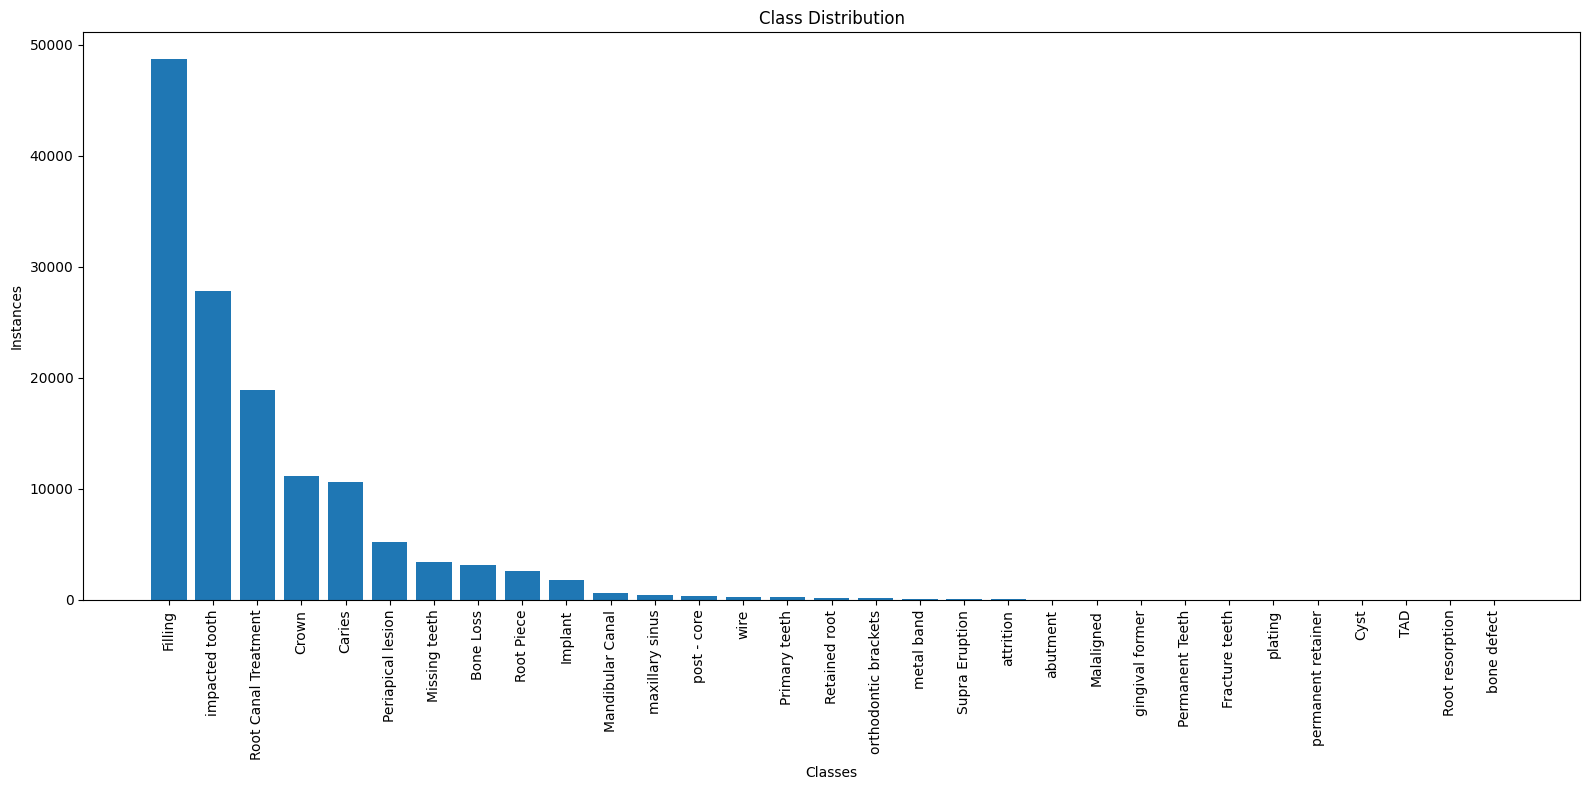

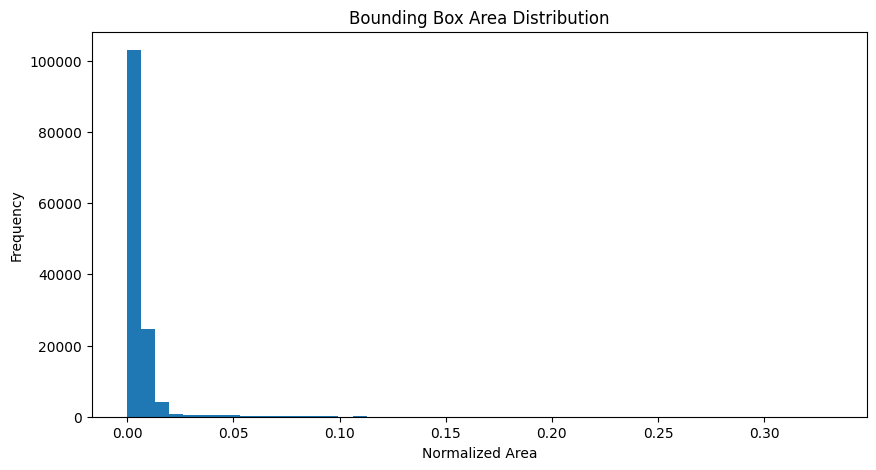

In [ ]:
import os
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from tqdm import tqdm

# ===================================
# DATASET PATH
# ===================================

DATASET_PATH = r"/content/drive/MyDrive/Dental X-Ray Panoramic Dataset.v2i.yolov11"

# ===================================
# LOAD YAML
# ===================================

with open(os.path.join(DATASET_PATH, "data.yaml"), 'r') as f:
    data = yaml.safe_load(f)

CLASS_NAMES = data['names']

print(f"\nTotal Classes: {len(CLASS_NAMES)}")

# ===================================
# VARIABLES
# ===================================

splits = ['train', 'valid', 'test']

class_counts = defaultdict(int)

bbox_areas = []
bbox_widths = []
bbox_heights = []

total_images = 0
total_labels = 0
empty_labels = 0

# ===================================
# PROCESS DATASET
# ===================================

for split in splits:

    print(f"\nProcessing {split}...")

    image_dir = os.path.join(DATASET_PATH, split, "images")
    label_dir = os.path.join(DATASET_PATH, split, "labels")

    image_files = os.listdir(image_dir)

    for image_file in tqdm(image_files):

        total_images += 1

        label_file = image_file.rsplit('.',1)[0] + ".txt"
        label_path = os.path.join(label_dir, label_file)

        if not os.path.exists(label_path):
            empty_labels += 1
            continue

        with open(label_path, 'r') as f:
            lines = f.readlines()

        if len(lines) == 0:
            empty_labels += 1
            continue

        for line in lines:

            values = line.strip().split()

            # segmentation needs > 5 values
            if len(values) < 7:
                continue

            cls = int(values[0])

            polygon = list(map(float, values[1:]))

            xs = polygon[0::2]
            ys = polygon[1::2]

            xmin = min(xs)
            xmax = max(xs)

            ymin = min(ys)
            ymax = max(ys)

            bw = xmax - xmin
            bh = ymax - ymin

            area = bw * bh

            class_counts[cls] += 1

            total_labels += 1

            bbox_widths.append(bw)
            bbox_heights.append(bh)
            bbox_areas.append(area)

# ===================================
# SUMMARY
# ===================================

print("\n========== DATASET SUMMARY ==========")

print(f"Total Images      : {total_images}")
print(f"Total Labels      : {total_labels}")
print(f"Empty Labels      : {empty_labels}")
print(f"Average Boxes/Image : {total_labels/total_images:.2f}")

# ===================================
# CLASS DISTRIBUTION
# ===================================

class_df = pd.DataFrame({
    "Class ID": list(class_counts.keys()),
    "Class Name": [CLASS_NAMES[i] for i in class_counts.keys()],
    "Count": list(class_counts.values())
})

class_df = class_df.sort_values(by="Count", ascending=False)

print("\nClass Distribution:")
print(class_df)

# SAVE CSV
class_df.to_csv("class_distribution.csv", index=False)

# ===================================
# CLASS DISTRIBUTION PLOT
# ===================================

plt.figure(figsize=(16,8))

plt.bar(class_df["Class Name"], class_df["Count"])

plt.xticks(rotation=90)

plt.title("Class Distribution")

plt.xlabel("Classes")
plt.ylabel("Instances")

plt.tight_layout()

plt.savefig("class_distribution.png")

plt.show()

# ===================================
# BBOX AREA DISTRIBUTION
# ===================================

plt.figure(figsize=(10,5))

plt.hist(bbox_areas, bins=50)

plt.title("Bounding Box Area Distribution")

plt.xlabel("Normalized Area")
plt.ylabel("Frequency")

plt.savefig("bbox_area_distribution.png")

plt.show()

In [ ]:
import os
import cv2
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# DATASET PATH
# ==========================================

DATASET_PATH = r"/content/drive/MyDrive/Dental X-Ray Panoramic Dataset.v2i.yolov11"

# ==========================================
# LOAD YAML
# ==========================================

with open(os.path.join(DATASET_PATH, "data.yaml"), 'r') as f:
    data = yaml.safe_load(f)

CLASS_NAMES = data['names']

# ==========================================
# DIRECTORIES
# ==========================================

image_dir = os.path.join(DATASET_PATH, "train", "images")
label_dir = os.path.join(DATASET_PATH, "train", "labels")

images = os.listdir(image_dir)

# ==========================================
# RANDOM SAMPLES
# ==========================================

sample_images = random.sample(images, 5)

# ==========================================
# VISUALIZATION
# ==========================================

for image_file in sample_images:

    image_path = os.path.join(image_dir, image_file)

    label_path = os.path.join(
        label_dir,
        image_file.rsplit('.', 1)[0] + '.txt'
    )

    image = cv2.imread(image_path)

    if image is None:
        print(f"Could not read image: {image_path}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    # ======================================
    # READ LABELS
    # ======================================

    if os.path.exists(label_path):

        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:

            values = line.strip().split()

            # segmentation requires many coordinates
            if len(values) < 7:
                continue

            cls = int(values[0])

            polygon = list(map(float, values[1:]))

            # ==================================
            # CONVERT NORMALIZED -> PIXELS
            # ==================================

            points = []

            for i in range(0, len(polygon), 2):

                x = int(polygon[i] * w)
                y = int(polygon[i+1] * h)

                points.append([x, y])

            points = np.array(points, dtype=np.int32)

            # ==================================
            # DRAW POLYGON
            # ==================================

            cv2.polylines(
                image,
                [points],
                isClosed=True,
                color=(0, 255, 0),
                thickness=2
            )

            # ==================================
            # DRAW CLASS NAME
            # ==================================

            x_text, y_text = points[0]

            cv2.putText(
                image,
                CLASS_NAMES[cls],
                (x_text, y_text - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                1
            )

    # ======================================
    # SHOW IMAGE
    # ======================================

    plt.figure(figsize=(12,12))

    plt.imshow(image)

    plt.title(image_file)

    plt.axis('off')

    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# STEP 1 — INSTALL LIBRARIES
# ============================================================

!pip install ultralytics opencv-python pyyaml tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.4 MB/s eta 0:00:00


In [ ]:
# ============================================================
# STEP 2 — IMPORTS
# ============================================================

import os
import cv2
import yaml
import shutil
import random
import numpy as np
from tqdm import tqdm
from ultralytics import YOLO


# ============================================================
# STEP 3 — DATASET PATHS
# ============================================================

ORIGINAL_DATASET = r"/content/drive/MyDrive/Dental X-Ray Panoramic Dataset.v2i.yolov11"

FILTERED_DATASET = r"/content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# ============================================================
# STEP 4 — CREATE FILTERED DATASET STRUCTURE
# ============================================================

splits = ["train", "valid", "test"]

for split in splits:

    os.makedirs(
        os.path.join(FILTERED_DATASET, split, "images"),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(FILTERED_DATASET, split, "labels"),
        exist_ok=True
    )


# ============================================================
# STEP 5 — TARGET CLASSES
# ============================================================

TARGET_CLASSES = {
    4: 0,    # Filling
    23: 1,   # impacted tooth
    14: 2,   # Root Canal Treatment
    2: 3,    # Crown
    1: 4,    # Caries
    10: 5,   # Periapical lesion
    9: 6,    # Missing teeth
    0: 7,    # Bone Loss
    15: 8,   # Root Piece
    6: 9     # Implant
}

NEW_CLASS_NAMES = [
    "Filling",
    "impacted tooth",
    "Root Canal Treatment",
    "Crown",
    "Caries",
    "Periapical lesion",
    "Missing teeth",
    "Bone Loss",
    "Root Piece",
    "Implant"
]

In [ ]:
# ============================================================
# STEP 6 — CLAHE PREPROCESSING FUNCTION
# ============================================================

def apply_clahe(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(gray)

    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

    return enhanced


# ============================================================
# STEP 7 — FILTER + PREPROCESS DATASET
# ============================================================

print("\nFiltering dataset...\n")

for split in splits:

    image_dir = os.path.join(
        ORIGINAL_DATASET,
        split,
        "images"
    )

    label_dir = os.path.join(
        ORIGINAL_DATASET,
        split,
        "labels"
    )

    output_image_dir = os.path.join(
        FILTERED_DATASET,
        split,
        "images"
    )

    output_label_dir = os.path.join(
        FILTERED_DATASET,
        split,
        "labels"
    )

    image_files = os.listdir(image_dir)

    for image_file in tqdm(image_files):

        image_path = os.path.join(image_dir, image_file)

        label_file = image_file.rsplit('.',1)[0] + ".txt"

        label_path = os.path.join(label_dir, label_file)

        if not os.path.exists(label_path):
            continue

        # ====================================================
        # READ LABELS
        # ====================================================

        filtered_lines = []

        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:

            values = line.strip().split()

            if len(values) < 7:
                continue

            old_class = int(values[0])

            if old_class in TARGET_CLASSES:

                new_class = TARGET_CLASSES[old_class]

                values[0] = str(new_class)

                filtered_lines.append(" ".join(values))

        # ====================================================
        # SKIP IMAGES WITHOUT TARGET CLASSES
        # ====================================================

        if len(filtered_lines) == 0:
            continue

        # ====================================================
        # READ IMAGE
        # ====================================================

        image = cv2.imread(image_path)

        if image is None:
            continue

        # ====================================================
        # APPLY CLAHE
        # ====================================================

        image = apply_clahe(image)

        # ====================================================
        # SAVE IMAGE
        # ====================================================

        output_image_path = os.path.join(
            output_image_dir,
            image_file
        )

        cv2.imwrite(output_image_path, image)

        # ====================================================
        # SAVE LABEL
        # ====================================================

        output_label_path = os.path.join(
            output_label_dir,
            label_file
        )

        with open(output_label_path, 'w') as f:

            for line in filtered_lines:
                f.write(line + "\n")


print("\nDataset filtering completed!")


# ============================================================
# STEP 8 — CREATE NEW DATA.YAML
# ============================================================

yaml_data = {
    'path': FILTERED_DATASET,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 10,
    'names': NEW_CLASS_NAMES
}

yaml_path = os.path.join(FILTERED_DATASET, "data.yaml")

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f)

print("\nNew YAML created!")


Filtering dataset...



100%|██████████| 1380/1380 [09:28<00:00,  2.43it/s]


Dataset filtering completed!

New YAML created!


In [ ]:
import os

print(os.listdir(FILTERED_DATASET))

['train', 'valid', 'test', 'data.yaml']


In [ ]:
import yaml
import os

FILTERED_DATASET = r"/content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset"

NEW_CLASS_NAMES = [
    "Filling",
    "impacted tooth",
    "Root Canal Treatment",
    "Crown",
    "Caries",
    "Periapical lesion",
    "Missing teeth",
    "Bone Loss",
    "Root Piece",
    "Implant"
]

yaml_data = {
    'path': FILTERED_DATASET,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 10,
    'names': NEW_CLASS_NAMES
}

yaml_path = os.path.join(FILTERED_DATASET, "data.yaml")

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f)

print("data.yaml successfully created!")

print("\nSaved at:")
print(yaml_path)

print("\nFiles inside dataset root:")
print(os.listdir(FILTERED_DATASET))

In [ ]:
# ============================================================
# STEP 9 — VERIFY FILTERED DATASET
# ============================================================

print("\nDataset Verification:\n")

for split in splits:

    image_count = len(
        os.listdir(
            os.path.join(
                FILTERED_DATASET,
                split,
                "images"
            )
        )
    )

    label_count = len(
        os.listdir(
            os.path.join(
                FILTERED_DATASET,
                split,
                "labels"
            )
        )
    )

    print(f"{split}")
    print(f"Images: {image_count}")
    print(f"Labels: {label_count}")
    print("-"*30)



Dataset Verification:

train
Images: 9658
Labels: 9658
------------------------------
valid
Images: 2756
Labels: 2756
------------------------------
test
Images: 1376
Labels: 1376
------------------------------


In [ ]:
# ============================================================
# STEP 10 — LOAD YOLOv8s-seg MODEL
# ============================================================

model = YOLO("yolov8s-seg.pt")

In [ ]:

# ============================================================
# STEP 11 — TRAIN MODEL
# ============================================================

model.train(

    # ======================================
    # DATASET
    # ======================================

    data="/content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset/data.yaml",

    # ======================================
    # MODEL TRAINING
    # ======================================

    epochs=100,
    imgsz=1024,
    batch=4,

    # ======================================
    # OPTIMIZATION
    # ======================================

    optimizer="AdamW",
    lr0=0.001,

    # ======================================
    # SEGMENTATION SETTINGS
    # ======================================

    overlap_mask=True,
    mask_ratio=4,

    # ======================================
    # AUGMENTATIONS
    # ======================================

    degrees=7,
    translate=0.05,
    scale=0.1,

    fliplr=0.0,
    flipud=0.0,

    mosaic=0.2,
    mixup=0.0,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.1,

    perspective=0.0001,

    # ======================================
    # TRAINING SETTINGS
    # ======================================

    device=0,
    workers=2,
    amp=True,
    cache=True,

    # ======================================
    # EARLY STOPPING
    # ======================================

    patience=20,

    # ======================================
    # OUTPUTS
    # ======================================

    project="/content/drive/MyDrive/OPG_Abhinaya/training_runs",

    name="yolov8s_seg_baseline",

    # ======================================
    # SAVE
    # ======================================

    save=True,
    save_period=10
)



Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset/data.yaml, degrees=7, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=0.2, multi_scale=0.0, name=yolov8s_seg_baseline-2, nbs=64, nms=False, opset=None, optimize=Fal

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/OPG_Abhinaya/training_runs/yolov8s_seg_baseline-2/weights/last.pt"
)

model.train(resume=True)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset/data.yaml, degrees=7, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/OPG_Abhinaya/training_runs/yolov8s_seg_baseline-2/weights/last.pt, momentum=0.937, mosaic=0.2, multi_scale=0.0

In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/OPG_Abhinaya/training_runs/yolov8s_seg_baseline-2/weights/best.pt"
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [ ]:
# ============================================================
# STEP 12 — VALIDATION
# ============================================================

metrics = model.val()

print(metrics)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8s-seg summary (fused): 86 layers, 11,783,470 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 3.0±4.2 ms, read: 0.3±0.1 MB/s, size: 91.4 KB)
val: Scanning /content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset/valid/labels.cache... 2756 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2756/2756 321.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 173/173 54.8s/it 2:38:06
                   all       2756      27374      0.694      0.683      0.673      0.404      0.674      0.657      0.642      0.334
               Filling       2009       9915      0.784      0.825      0.812      0.492      0.781      0.815      0.798      0.435
        impacted tooth       2295       5590      0.913       0.97      0.959       0.64      0.916      0.969       0.96      0.5

In [ ]:
import shutil
import os

PREDICTION_FOLDER = (
    "/content/drive/MyDrive/OPG_Abhinaya/"
    "predictions/test_predictions-2"
)

if os.path.exists(PREDICTION_FOLDER):
    shutil.rmtree(PREDICTION_FOLDER)
    print("Old prediction folder deleted!")

else:
    print("Prediction folder not found.")

Old prediction folder deleted!


In [ ]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print("GPU cache cleared!")

GPU cache cleared!


In [ ]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/OPG_Abhinaya/"
    "training_runs/yolov8s_seg_baseline-2/"
    "weights/best.pt"
)

print("Model loaded!")

Model loaded!


In [ ]:
test_images = (
    "/content/drive/MyDrive/OPG_Abhinaya/"
    "filtered_opg_dataset/test/images"
)

results = model.predict(

    source=test_images,

    imgsz=1024,

    conf=0.50,

    batch=1,

    stream=True,

    save=True,

    project="/content/drive/MyDrive/OPG_Abhinaya/predictions",

    name="best_model_predictions"
)

for _ in results:
    pass

print("Prediction completed successfully!")


image 1/1376 /content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset/test/images/00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.2daa35d07d1a6e0861048b1ad4d4a6e1.jpg: 1024x1024 9 Fillings, 5 Root Canal Treatments, 10 Crowns, 1 Periapical lesion, 43.2ms
image 2/1376 /content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset/test/images/00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.d4ce5492a08cce959e3cda6f9f631a81.jpg: 1024x1024 9 Fillings, 5 Root Canal Treatments, 10 Crowns, 1 Periapical lesion, 40.0ms
image 3/1376 /content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset/test/images/01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.rf.6cc74cb86992f89338e4cf6469800831.jpg: 1024x1024 5 Fillings, 5 Root Canal Treatments, 1 Caries, 1 Missing teeth, 1 Root Piece, 39.9ms
image 4/1376 /content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset/test/images/01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.rf.f4e35f0f478b6c9c897a0adb1a9811d3.jpg: 1024x1024 5 Fillings, 5 Root Canal Treatments,

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

PRED_DIR = (
    "/content/drive/MyDrive/OPG_Abhinaya/"
    "predictions/best_model_predictions"
)

# Ultralytics usually saves inside predict/
PRED_IMAGES_DIR = os.path.join(PRED_DIR)

images = [
    f for f in os.listdir(PRED_IMAGES_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total prediction images:", len(images))

sample_images = random.sample(
    images,
    min(9, len(images))
)

plt.figure(figsize=(18,18))

for i, image_file in enumerate(sample_images):

    image_path = os.path.join(
        PRED_IMAGES_DIR,
        image_file
    )

    image = cv2.imread(image_path)
    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(image_file[:30])

    plt.axis("off")

plt.tight_layout()

plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os
import cv2
import random
import yaml
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

DATASET_PATH = "/content/drive/MyDrive/OPG_Abhinaya/filtered_opg_dataset"

PREDICTION_PATH = (
    "/content/drive/MyDrive/OPG_Abhinaya/"
    "predictions/best_model_predictions"
)

# ============================================================
# LOAD CLASS NAMES
# ============================================================

with open(
    os.path.join(DATASET_PATH, "data.yaml"),
    "r"
) as f:

    data = yaml.safe_load(f)

CLASS_NAMES = data["names"]

# ============================================================
# RANDOM TEST IMAGES
# ============================================================

test_image_dir = os.path.join(
    DATASET_PATH,
    "test",
    "images"
)

test_label_dir = os.path.join(
    DATASET_PATH,
    "test",
    "labels"
)

all_images = os.listdir(test_image_dir)

sample_images = random.sample(
    all_images,
    5
)

# ============================================================
# VISUALIZE
# ============================================================

for image_file in sample_images:

    # ========================================================
    # ORIGINAL IMAGE
    # ========================================================

    original_path = os.path.join(
        test_image_dir,
        image_file
    )

    original = cv2.imread(original_path)

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    # ========================================================
    # GROUND TRUTH IMAGE
    # ========================================================

    gt_image = original.copy()

    label_file = image_file.rsplit(".",1)[0] + ".txt"

    label_path = os.path.join(
        test_label_dir,
        label_file
    )

    h, w = gt_image.shape[:2]

    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            lines = f.readlines()

        for line in lines:

            values = line.strip().split()

            cls = int(values[0])

            points = list(
                map(float, values[1:])
            )

            polygon = []

            for i in range(
                0,
                len(points),
                2
            ):

                x = int(points[i] * w)
                y = int(points[i+1] * h)

                polygon.append([x,y])

            polygon = np.array(
                polygon,
                dtype=np.int32
            )

            cv2.polylines(
                gt_image,
                [polygon],
                True,
                (0,255,0),
                2
            )

            cv2.putText(
                gt_image,
                CLASS_NAMES[cls],
                tuple(polygon[0]),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255,0,0),
                1
            )

    # ========================================================
    # PREDICTION IMAGE
    # ========================================================

    pred_path = os.path.join(
        PREDICTION_PATH,
        image_file
    )

    prediction = cv2.imread(pred_path)

    prediction = cv2.cvtColor(
        prediction,
        cv2.COLOR_BGR2RGB
    )

    # ========================================================
    # DISPLAY
    # ========================================================

    plt.figure(figsize=(24,8))

    plt.subplot(1,3,1)

    plt.imshow(original)

    plt.title("Original")

    plt.axis("off")

    plt.subplot(1,3,2)

    plt.imshow(gt_image)

    plt.title("Ground Truth")

    plt.axis("off")

    plt.subplot(1,3,3)

    plt.imshow(prediction)

    plt.title("Prediction")

    plt.axis("off")

    plt.tight_layout()

    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# STEP 14 — BEST MODEL LOCATION
# ============================================================

print("\nTraining Completed!")

print("\nBest Model Path:")

print(
    "/content/drive/MyDrive/OPG_Abhinaya/training_runs/"
    "yolov8s_seg_baseline/weights/best.pt"
)


Training Completed!

Best Model Path:
/content/drive/MyDrive/OPG_Abhinaya/training_runs/yolov8s_seg_baseline/weights/best.pt
